Breast cancer is one of the most prevalent cancers among females globally. Accurate early diagnosis based on cell nucleus features can significantly improve survival rates.
The Breast Cancer Wisconsin (Diagnostic) Dataset contains 569 samples with 30 numerical features extracted from fine needle aspiration images of breast mass cells. The dataset is labeled into two categories:

* **Benign:** Non-cancerous
* **Malignant:** Cancerous


Original high-dimensional features suffer from strong multicollinearity, which increases model complexity and reduces interpretability. This notebook applies Principal Component Analysis (PCA) to:

1. Explore feature correlation and data distribution
2. Standardize feature scales for stable PCA performance
3. Reduce 30D features into low-dimensional principal components
4. Retain over 95% cumulative variance5, Visualize cluster separation between benign and malignant samples6, Interpret feature contributions via loading analysis


**Dataset Overview**


* Total Samples: 569
* Benign: 357 | Malignant: 212
* Feature Dimension: 30 continuous nucleus features
* No missing valuesSevere multicollinearity among original features


In [1]:
# Import Libraries & Environment Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Kaggle compatible font setting
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

In [2]:
# Load dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target
target_names = ['Benign', 'Malignant']

# Check shape
print(f"Feature Shape: {X.shape}")
print(f"Label Shape: {y.shape}")
X.head()

Feature Shape: (569, 30)
Label Shape: (569,)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


****


In [3]:
# Feature Standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

**PCA Model Fitting**

In [4]:
# PCA fitting
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Variance explanation
exp_var = pca.explained_variance_ratio_
cum_var = np.cumsum(exp_var)

# Calculate feature loadings
loadings = pca.components_.T * np.sqrt(exp_var)

**Visualization Analysis**

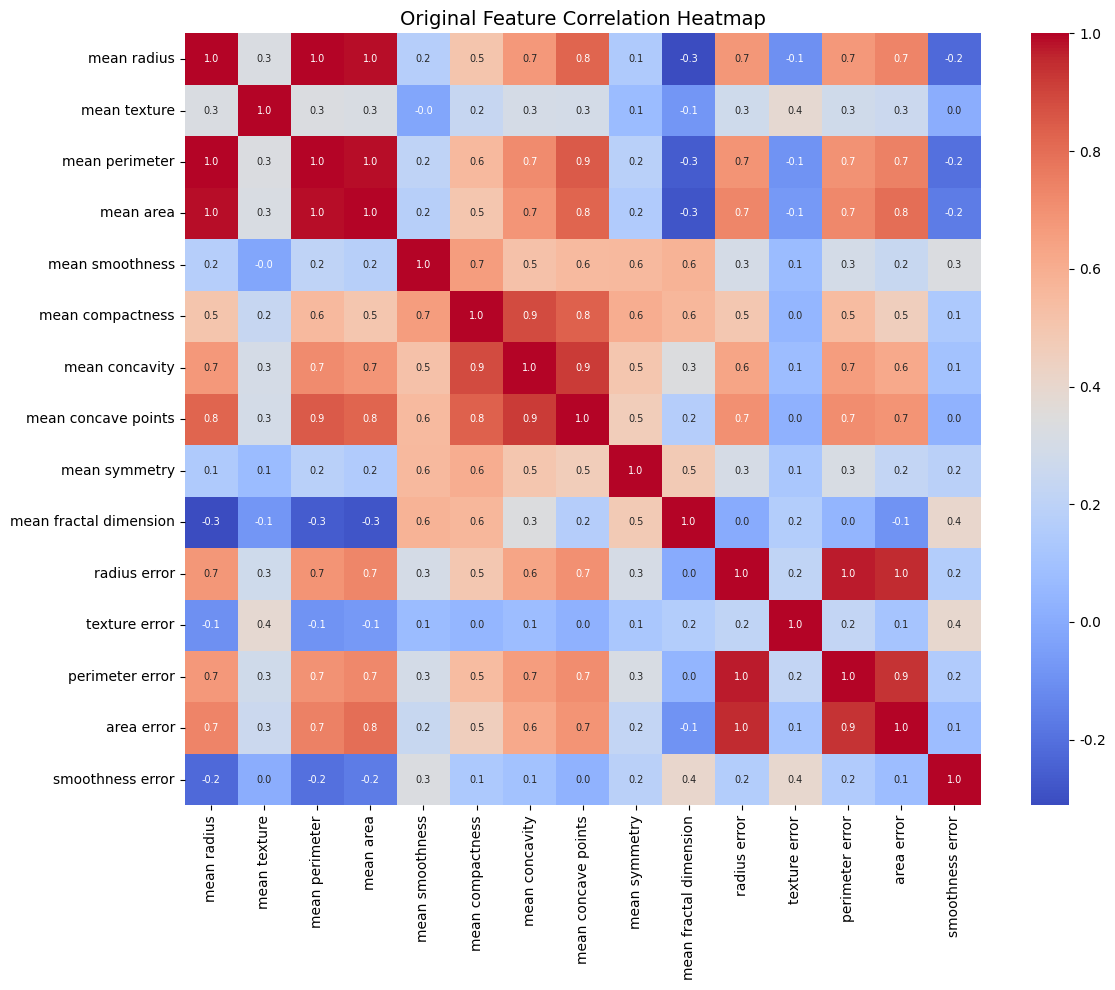

In [5]:
# Plot 1: Original Feature Correlation Heatmap
plt.figure(figsize=(12,10))
plt.title("Original Feature Correlation Heatmap", fontsize=14)
sns.heatmap(
    X.iloc[:, :15].corr(),
    cmap="coolwarm",
    annot=True,
    fmt='.1f',
    annot_kws={"size":7}
)
plt.tight_layout()
plt.show()

**Insight:** Many features show strong positive correlation, proving the necessity of dimensionality reduction.

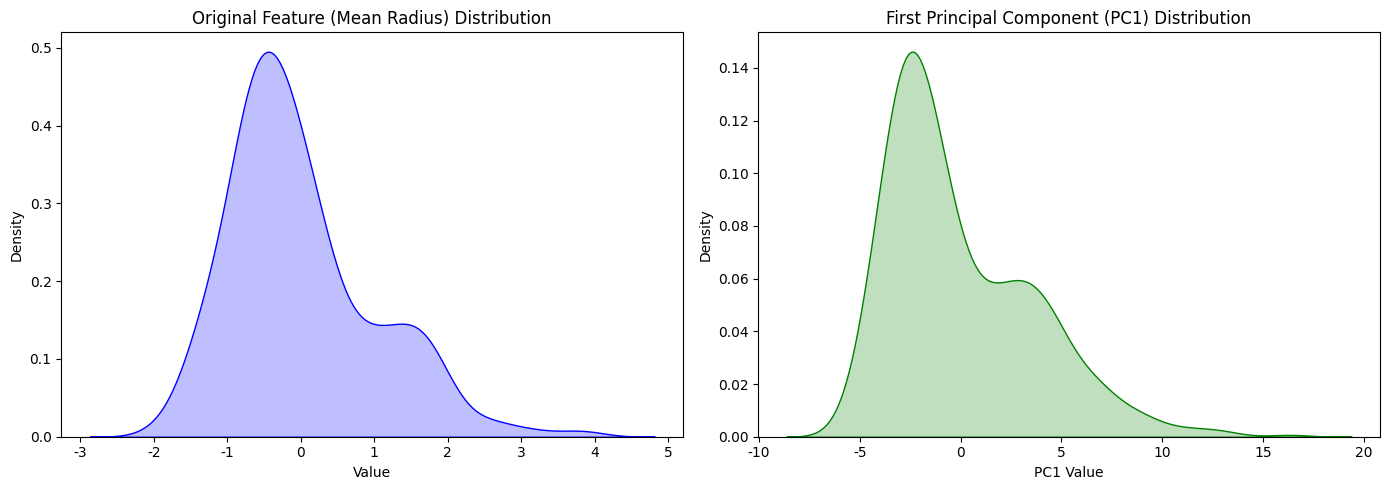

In [6]:
# Plot 2: Distribution Comparison — Original Feature vs PC1
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))

# Original feature: Mean Radius
sns.kdeplot(X_scaled[:,0], fill=True, color='blue', ax=ax1)
ax1.set_title("Original Feature (Mean Radius) Distribution", fontsize=12)
ax1.set_xlabel("Value")
ax1.set_ylabel("Density")

# First Principal Component PC1
sns.kdeplot(X_pca[:,0], fill=True, color='green', ax=ax2)
ax2.set_title("First Principal Component (PC1) Distribution", fontsize=12)
ax2.set_xlabel("PC1 Value")
ax2.set_ylabel("Density")

plt.tight_layout()
plt.show()

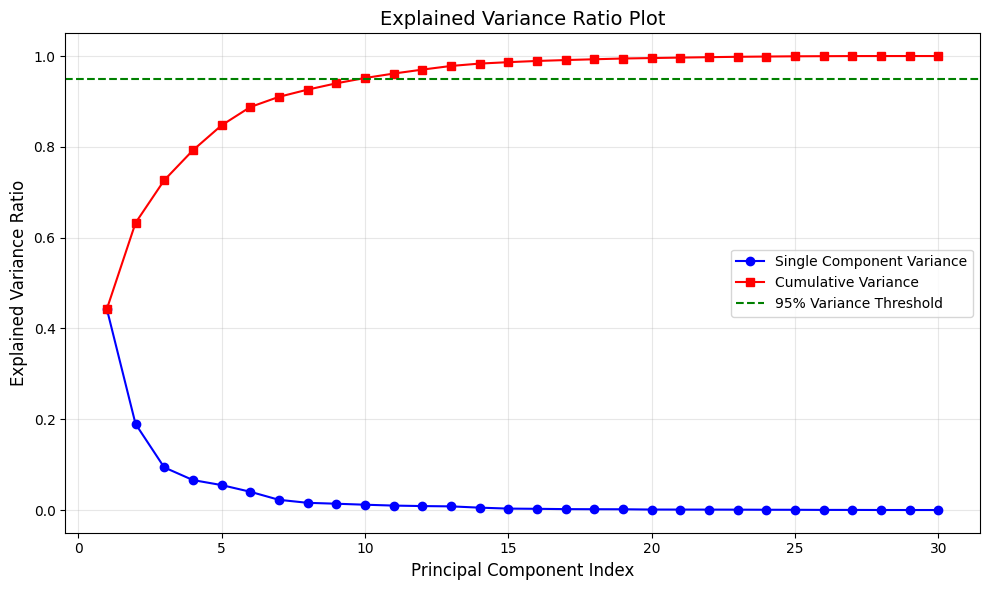

In [7]:
# Plot 3: Explained Variance & Cumulative Variance
plt.figure(figsize=(10,6))
plt.plot(range(1, len(exp_var)+1), exp_var, 'o-', color="blue", label="Single Component Variance")
plt.plot(range(1, len(cum_var)+1), cum_var, 's-', color="red", label="Cumulative Variance")
plt.axhline(y=0.95, color="green", linestyle="--", label="95% Variance Threshold")

plt.xlabel("Principal Component Index", fontsize=12)
plt.ylabel("Explained Variance Ratio", fontsize=12)
plt.title("Explained Variance Ratio Plot", fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Insight:**  Only about 10 principal components can preserve 95% information of original 30 features.

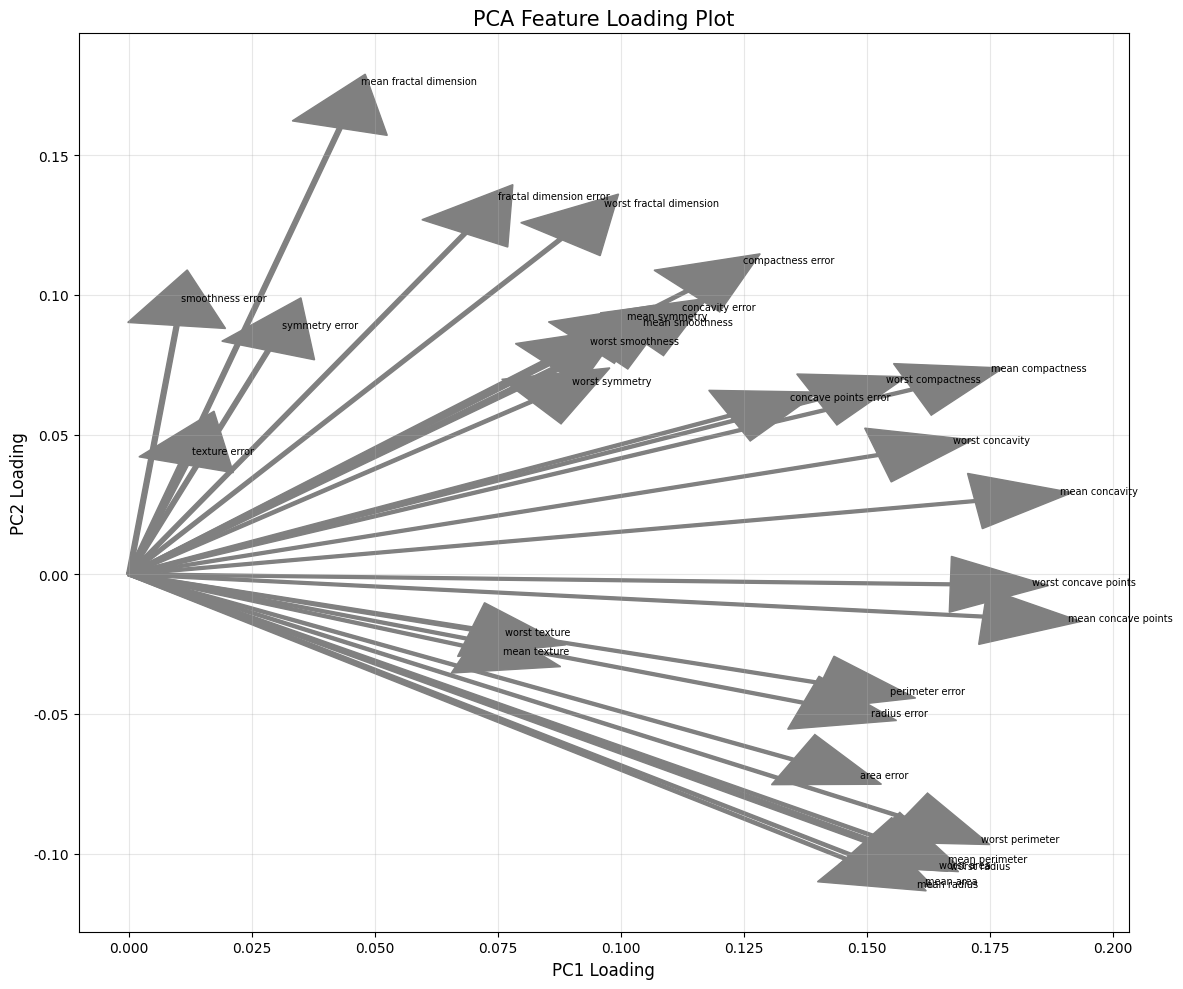

In [8]:
# Plot 4: PCA Feature Loading Plot (PC1 vs PC2)
plt.figure(figsize=(12,10))
plt.xlabel("PC1 Loading", fontsize=12)
plt.ylabel("PC2 Loading", fontsize=12)
plt.title("PCA Feature Loading Plot", fontsize=15)
plt.grid(alpha=0.3)

for i, feature in enumerate(X.columns):
    plt.arrow(0, 0, loadings[i,0], loadings[i,1],
              head_width=0.02, head_length=0.02, color="gray")
    plt.text(loadings[i,0]*1.1, loadings[i,1]*1.1, feature, fontsize=7)

plt.tight_layout()
plt.show()

**Insight:** Features with longer vectors contribute more to PC1 and PC2.

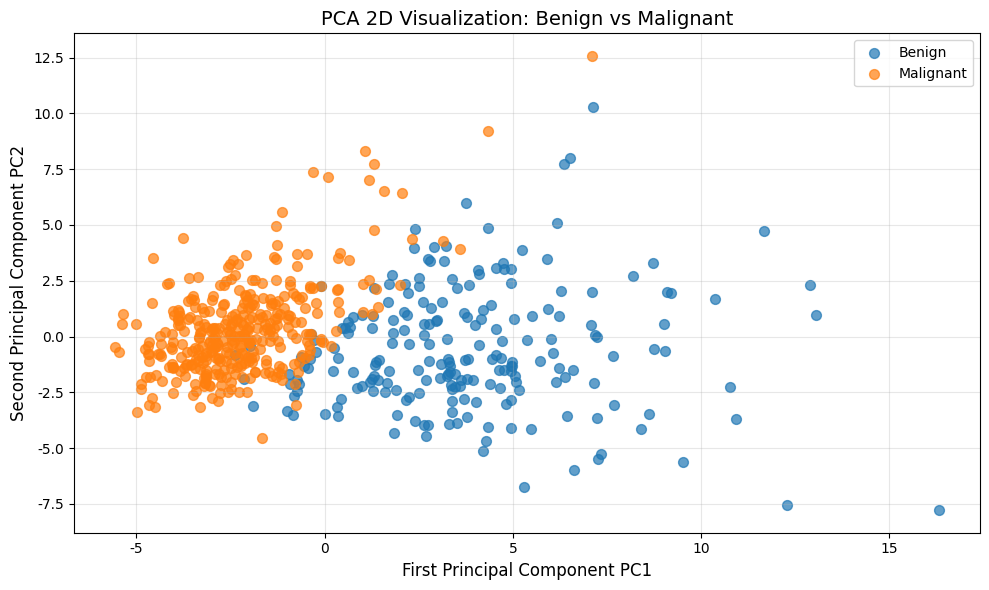

In [9]:
# Plot 5: PCA 2D Scatter Plot (Benign vs Malignant)
plt.figure(figsize=(10,6))
for i, name in enumerate(target_names):
    plt.scatter(
        X_pca[y==i, 0],
        X_pca[y==i, 1],
        label=name,
        alpha=0.7,
        s=50
    )

plt.xlabel("First Principal Component PC1", fontsize=12)
plt.ylabel("Second Principal Component PC2", fontsize=12)
plt.title("PCA 2D Visualization: Benign vs Malignant", fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Insight:** Benign and malignant samples are clearly separated in the 2D PCA space.

**Results & Discussion**

Two principal components can well distinguish benign and malignant breast cancer samples, supporting further classification modeling. The original 30 features have strong multicollinearity, which PCA effectively eliminates. PCA reduces feature dimension greatly while retaining over 95% original information. Key nucleus features such as radius, perimeter and concave points dominate principal components.